# Linear Regression 

## Multiple Linear Regression
We want to predict a continuous variable y (Dependent Variable) based on multiple input x (Independent Variable).

In real world, **Salary isn't just based on Experience**. It's also based on Education Level, City Cost of Living, etc.

Instead of a 2D line, we are now dealing with a **Hyperplane**. The equation evolves from `y = mx + b` to:
y = $m_{0}$ + $m_{1}$ $x_{1}$ + $m_{2}$ $x_{2}$ + ... + $m_{n}$ $x_{n}$

Instead of writing this long equation for every single row of data, we use `Matrices` to do it all at once.
- y: A vector of targets
- X: A matrix of features
- m: A vector of coefficients

In the above equation, b is lonely. It doesn't have an x. To make the math consistant, we pretend b is multiplied by 1.

y = ($m_{0}$ . 1) + ($m_{1}$ . $x_{1}$) + ($m_{2}$ . $x_{2})$ + ... + ... + ($m_{n}$ . $x_{n}$)

> The equation becomes: `y = X.m`

> To solve for m, we use the Normal Equation: m = ($X^{T}$X)<sup>-1</sup> $X^{T}$y

Let's organize it into matrices:

**Matrix X (Features):** Each row is an observation. We add a column of 1s at the start.

$$
X = \begin{bmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{bmatrix}
$$

**Vector m (Weights/Coefficients):** This is what the model needs to learn.
$$
m = \begin{bmatrix}
b \\
m_{1} \\
m_{2}
\end{bmatrix}
$$

**X.m:** When we multiply a row of X by the column m, we get:
(1 . $m_{0}$) + ($x_{11}$ . $m_{1}$) + ($x_{12}$ . $m_{2}$)

## Multicolinearity in Multiple Linear Regression
Multicolinearity arises when two or more independent variables are highly correlated with each other. To detect multicolinearity we can use:
1. **Correlation Matrix**, which helps to find relationships between independent variables.
2. **VIF (Variance Inflation Factor)**, which quantifies how much the variance of a regression coefficient increases if predictors are correlated.

## Multiple Linear Regression from Scratch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class MultipleLinearRegression:
    def __init__(self):
        self.weights = None

    def fit(self, X, y):
        # Add a column of 1s to X for the intercept
        X = np.c_[np.ones(X.shape[0]), X]

        # Solve the weights using the Normal Equation
        x_transpose = np.transpose(X)
        self.weights = np.linalg.inv(x_transpose.dot(X)).dot(x_transpose).dot(y)
        print(f"Weights (including intercept): {self.weights}")

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return np.dot(X, self.weights)

    def r2_score(self, y_actual, y_predicted):
        y_mean = np.mean(y_actual)
        ss_residuals = np.sum((y_actual - y_predicted) ** 2)
        ss_total = np.sum((y_actual - y_mean) ** 2)
        return f"R2 Score: {(1 - (ss_residuals / ss_total)):.2f}"

In [3]:
# Creates a dummy dataset

# Features: [Experience, Education_level]
X = np.array([[1, 1], [2, 1], [3, 2], [4, 2], [5, 3], [6, 3]]) 
y = np.array([45000, 50000, 70000, 80000, 110000, 130000]) # Salary

# Train The Model
model = MultipleLinearRegression()
model.fit(X, y)

# Predict
y_pred = model.predict(X)

# Performance Metrics
r2 = model.r2_score(y, y_pred)
print(r2)
print(f"{y_pred.tolist()}")

Weights (including intercept): [14166.66666667 11666.66666667 12916.66666667]
R2 Score: 0.97
[38750.000000000655, 50416.66666666734, 75000.00000000067, 86666.66666666736, 111250.00000000068, 122916.66666666737]


## Implement Multiple Linear Regression using Scikit-learn

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Loading the Dataset
california_housing = fetch_california_housing()
X = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y = pd.Series(california_housing.target)

In [6]:
# Selecting Features for Visualization
X = X[['MedInc', 'AveRooms']]

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,MedInc,AveRooms
14196,3.2596,5.017657
8267,3.8125,4.473545
17445,4.1563,5.645833
14265,1.9425,4.002817
2271,3.5542,6.268421


In [8]:
# Initializing and Training Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Make Predictions
y_pred = model.predict(X_test)
y_pred

array([1.16230214, 1.49913482, 1.95573059, ..., 4.33311942, 1.59978552,
       1.98667198])

In [10]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Length: 4128, dtype: float64

In [11]:
# Finding Intercept and Slopes
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Coefficients: [ 0.43626089 -0.04017161]
Intercept: 0.5972677793933256


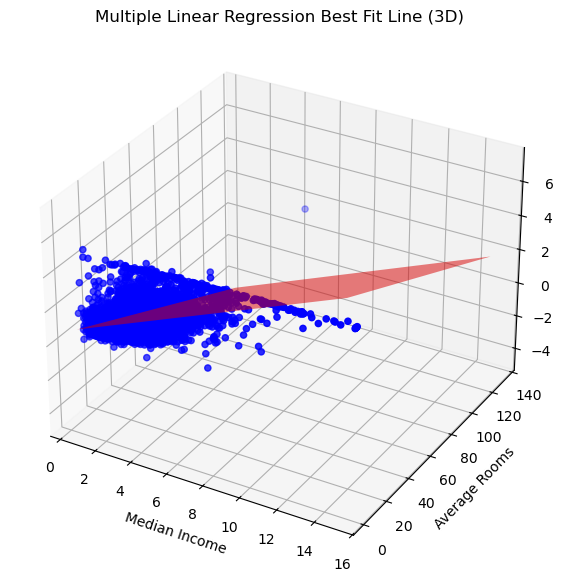

In [12]:
# Visualizing the Best-fit line in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_test['MedInc'], X_test['AveRooms'],y_test, color='blue', label='Actual Data')

x1_range = np.linspace(X_test['MedInc'].min(), X_test['MedInc'].max(), 100)
x2_range = np.linspace(X_test['AveRooms'].min(), X_test['AveRooms'].max(), 100)
x1, x2 = np.meshgrid(x1_range, x2_range)

z = model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape)

ax.plot_surface(x1, x2, z, color='red', alpha=0.5, rstride=100, cstride=100)
ax.set_xlabel('Median Income')
ax.set_ylabel('Average Rooms')
ax.set_zlabel('House Price')
ax.set_title('Multiple Linear Regression Best Fit Line (3D)')
plt.show()